# Noise Sensitivity Experiments
**IDS 705 Final Project — Group 7: The Floodgates**

This notebook is fully self-contained. It:
1. Loads the raw dataset
2. Runs data quality checks
3. Splits into clean train/test sets (no noise injection)
4. Fits the scaler on training data only
5. Runs systematic noise sensitivity experiments
6. Produces visualizations identifying which features/noise types matter
7. Applies experimentally-informed noise to the training set
8. Saves final model-ready splits for 01_modeling.ipynb

### Why this ordering?
- Train/test split happens before any noise injection to prevent leakage
- Noise experiments run on clean training data only
- Final noise applied is justified by experiments, not assumed
- Test set remains clean throughout

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBRegressor

import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10

SEED = 42
np.random.seed(SEED)

## 1. Load Raw Data & Initial Inspection

In [2]:
df = pd.read_csv("data/flood.csv")

print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()

Shape: (50000, 21)
Rows: 50,000 | Columns: 21


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   MonsoonIntensity                 50000 non-null  int64  
 1   TopographyDrainage               50000 non-null  int64  
 2   RiverManagement                  50000 non-null  int64  
 3   Deforestation                    50000 non-null  int64  
 4   Urbanization                     50000 non-null  int64  
 5   ClimateChange                    50000 non-null  int64  
 6   DamsQuality                      50000 non-null  int64  
 7   Siltation                        50000 non-null  int64  
 8   AgriculturalPractices            50000 non-null  int64  
 9   Encroachments                    50000 non-null  int64  
 10  IneffectiveDisasterPreparedness  50000 non-null  int64  
 11  DrainageSystems                  50000 non-null  int64  
 12  CoastalVulnerabili

## 2. Data Quality Checks

In [4]:
TARGET = "FloodProbability"
FEATURES = [c for c in df.columns if c != TARGET]

# Missing values
missing = df.isnull().sum()
print("Missing values:")
print(missing[missing > 0] if missing.sum() > 0 else "None — dataset is complete.")

# Duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Value ranges
print("\nFeature min/max:")
print(df[FEATURES].agg(["min", "max"]))

Missing values:
None — dataset is complete.

Duplicate rows: 0

Feature min/max:
     MonsoonIntensity  TopographyDrainage  RiverManagement  Deforestation  \
min                 0                   0                0              0   
max                16                  18               16             17   

     Urbanization  ClimateChange  DamsQuality  Siltation  \
min             0              0            0          0   
max            17             17           16         16   

     AgriculturalPractices  Encroachments  IneffectiveDisasterPreparedness  \
min                      0              0                                0   
max                     16             18                               16   

     DrainageSystems  CoastalVulnerability  Landslides  Watersheds  \
min                0                     0           0           0   
max               17                    17          16          16   

     DeterioratingInfrastructure  PopulationScore  WetlandLo

In [5]:
# Summary statistics
print("Summary statistics:")
df.describe().round(2)

Summary statistics:


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,...,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,4.99,4.98,5.02,5.01,4.99,4.99,5.02,4.99,5.01,5.01,...,5.01,5.00,4.98,4.98,4.99,4.98,5.01,4.99,4.99,0.50
std,2.24,2.25,2.23,2.22,2.24,2.23,2.24,2.23,2.23,2.24,...,2.24,2.25,2.23,2.23,2.23,2.24,2.23,2.23,2.25,0.05
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.28
25%,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,...,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,0.46
50%,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,0.50
75%,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,...,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,0.54
max,16.00,18.00,16.00,17.00,17.00,17.00,16.00,16.00,16.00,18.00,...,17.00,17.00,16.00,16.00,17.00,19.00,22.00,16.00,16.00,0.72


FloodProbability summary:
count    50000.000000
mean         0.499660
std          0.050034
min          0.285000
25%          0.465000
50%          0.500000
75%          0.535000
max          0.725000
Name: FloodProbability, dtype: float64


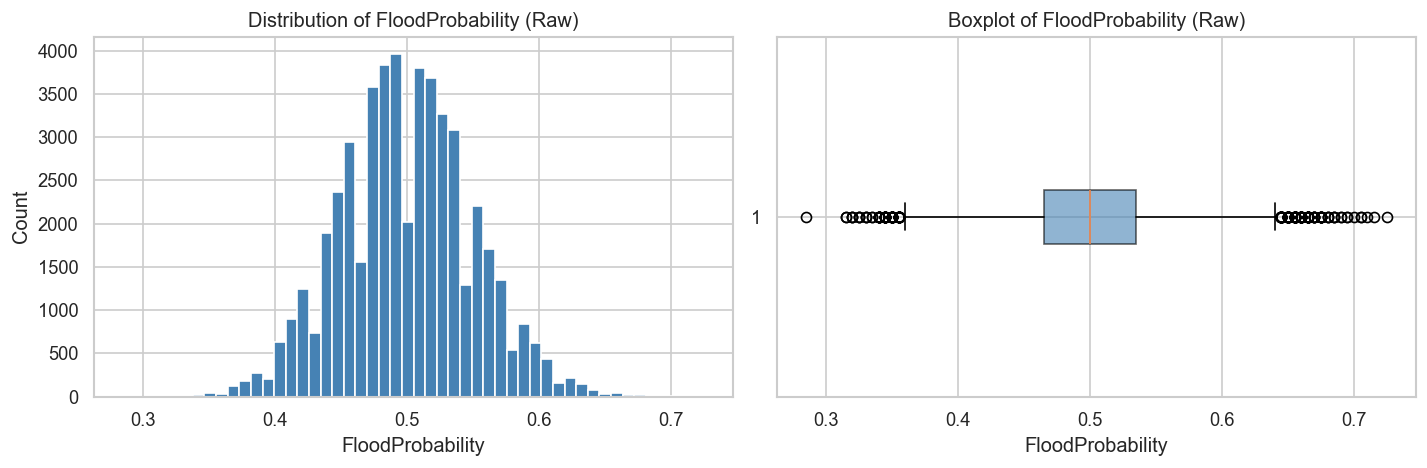

In [6]:
# Target distribution
print("FloodProbability summary:")
print(df[TARGET].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df[TARGET], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of FloodProbability (Raw)")
axes[0].set_xlabel("FloodProbability")
axes[0].set_ylabel("Count")
axes[1].boxplot(
    df[TARGET],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.6),
)
axes[1].set_title("Boxplot of FloodProbability (Raw)")
axes[1].set_xlabel("FloodProbability")
plt.tight_layout()
plt.show()

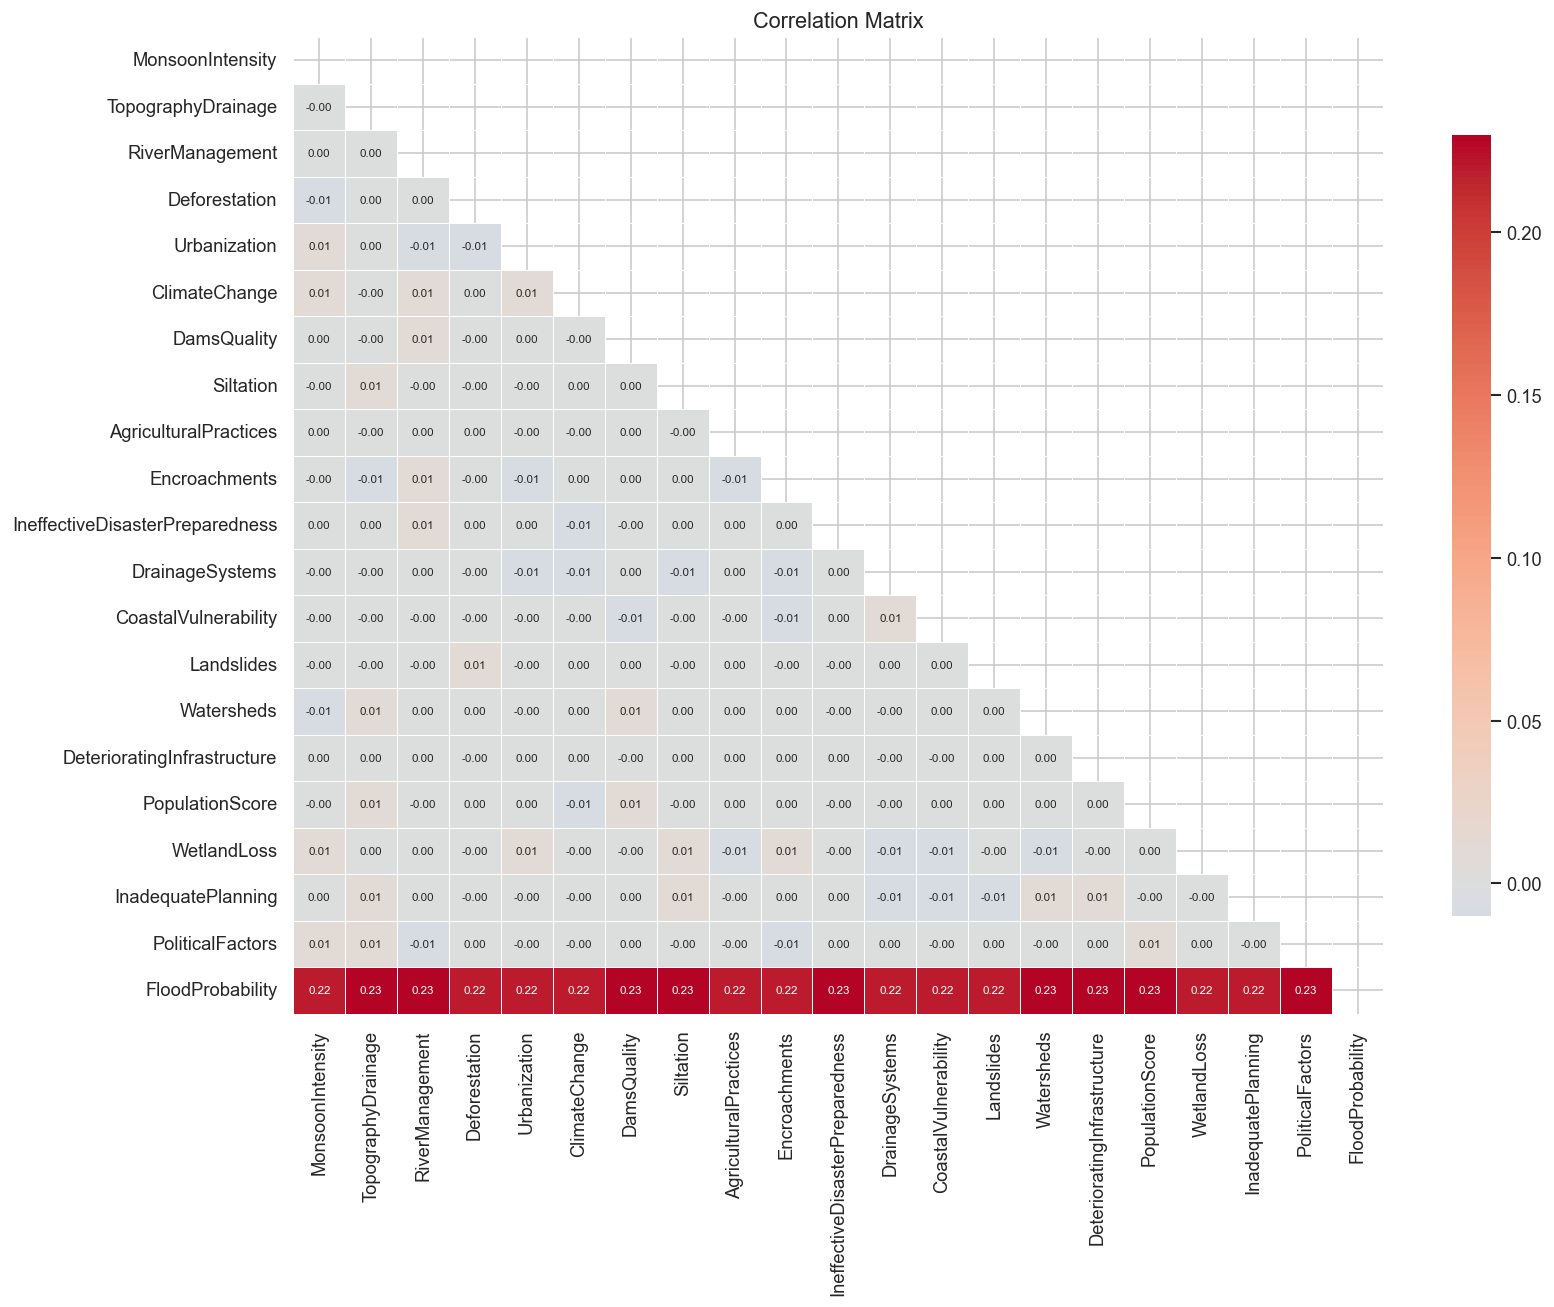

In [7]:
# Correlation matrix
fig, ax = plt.subplots(figsize=(14, 11))
corr = df.corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    ax=ax,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    annot_kws={"size": 7},
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Correlation Matrix", fontsize=13)
plt.tight_layout()
plt.show()

VIF Scores:
                        Feature      VIF
                RiverManagement 5.768622
                  Deforestation 5.767390
IneffectiveDisasterPreparedness 5.759679
                    WetlandLoss 5.733906
             InadequatePlanning 5.720768
    DeterioratingInfrastructure 5.719147
                  ClimateChange 5.716725
          AgriculturalPractices 5.716662
                     Landslides 5.710010
                      Siltation 5.707089
                    DamsQuality 5.704095
                     Watersheds 5.697504
                DrainageSystems 5.692088
               MonsoonIntensity 5.687697
                  Encroachments 5.679066
                PopulationScore 5.676945
                   Urbanization 5.649954
               PoliticalFactors 5.649217
             TopographyDrainage 5.647835
           CoastalVulnerability 5.636271


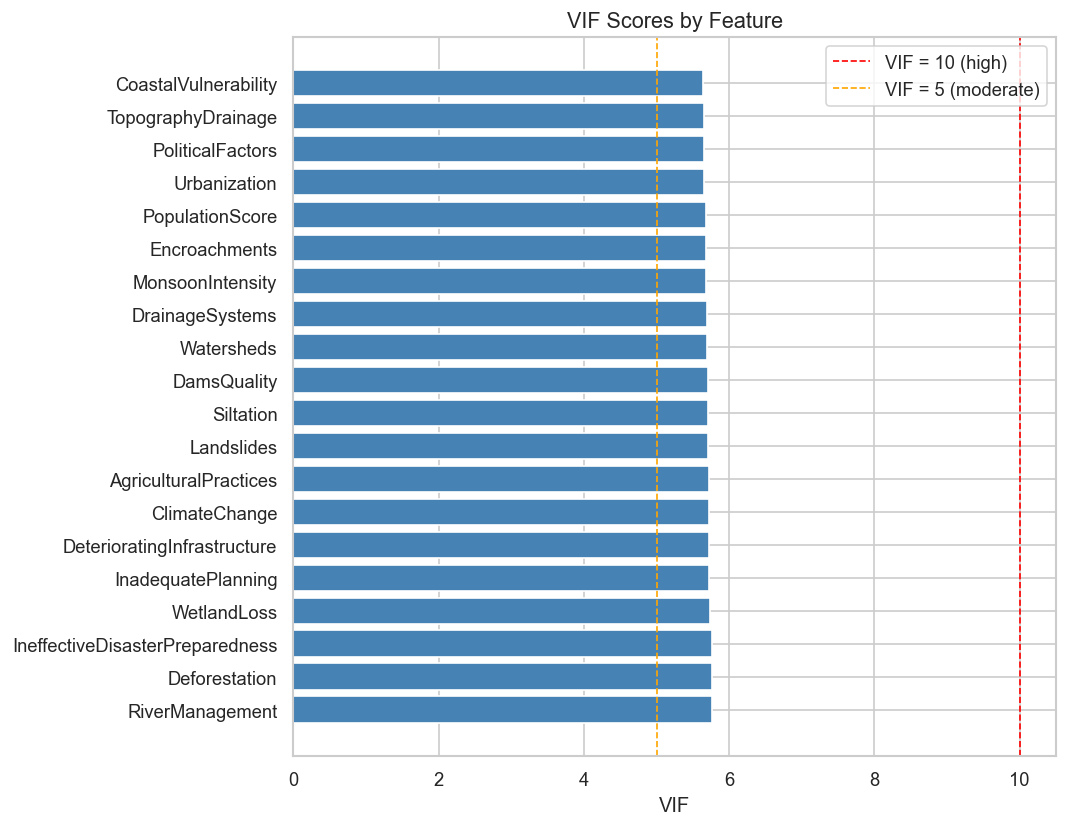

In [8]:
# VIF analysis
vif_data = (
    pd.DataFrame(
        {
            "Feature": FEATURES,
            "VIF": [
                variance_inflation_factor(df[FEATURES].values, i)
                for i in range(len(FEATURES))
            ],
        }
    )
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

print("VIF Scores:")
print(vif_data.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["salmon" if v > 10 else "steelblue" for v in vif_data["VIF"]]
ax.barh(vif_data["Feature"], vif_data["VIF"], color=colors, edgecolor="white")
ax.axvline(10, color="red", linestyle="--", linewidth=1, label="VIF = 10 (high)")
ax.axvline(5, color="orange", linestyle="--", linewidth=1, label="VIF = 5 (moderate)")
ax.set_title("VIF Scores by Feature", fontsize=13)
ax.set_xlabel("VIF")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Train / Test Split — CLEAN (no noise yet)

Split happens here, before any noise. The test set will never see noise at any point.

In [9]:
X = df[FEATURES].copy()
y = df[TARGET].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f"Training set : {X_train_raw.shape[0]:,} rows")
print(f"Test set     : {X_test_raw.shape[0]:,} rows")
print(
    f"Train target mean: {y_train.mean():.4f} | Test target mean: {y_test.mean():.4f}"
)

Training set : 40,000 rows
Test set     : 10,000 rows
Train target mean: 0.4995 | Test target mean: 0.5002


In [10]:
# Fit scaler on TRAINING data only
scaler = StandardScaler()
X_train_clean = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=FEATURES)
X_test_clean = pd.DataFrame(scaler.transform(X_test_raw), columns=FEATURES)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("Scaler fit on training set only — no leakage.")
print(f"X_train_clean: {X_train_clean.shape}")
print(f"X_test_clean : {X_test_clean.shape}")

Scaler fit on training set only — no leakage.
X_train_clean: (40000, 20)
X_test_clean : (10000, 20)


In [11]:
# 5-fold CV object for use in modeling notebook
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
print("5-fold CV split sizes (on training set):")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_clean), 1):
    print(f"  Fold {fold}: train={len(train_idx):,} | val={len(val_idx):,}")

5-fold CV split sizes (on training set):
  Fold 1: train=32,000 | val=8,000
  Fold 2: train=32,000 | val=8,000
  Fold 3: train=32,000 | val=8,000
  Fold 4: train=32,000 | val=8,000
  Fold 5: train=32,000 | val=8,000


## 4. Feature Groups
Categorize features by their real-world measurement type for color-coded plots.

In [12]:
FEATURE_GROUPS = {
    "Physical / Environmental": [
        "MonsoonIntensity",
        "TopographyDrainage",
        "Siltation",
        "CoastalVulnerability",
        "Landslides",
        "Watersheds",
        "WetlandLoss",
    ],
    "Infrastructure": [
        "RiverManagement",
        "DamsQuality",
        "DrainageSystems",
        "DeterioratingInfrastructure",
    ],
    "Human / Land Use": [
        "Deforestation",
        "Urbanization",
        "AgriculturalPractices",
        "Encroachments",
        "PopulationScore",
    ],
    "Socio-Political": [
        "ClimateChange",
        "IneffectiveDisasterPreparedness",
        "InadequatePlanning",
        "PoliticalFactors",
    ],
}

FEAT_TO_GROUP = {}
for group, feats in FEATURE_GROUPS.items():
    for f in feats:
        if f in FEATURES:
            FEAT_TO_GROUP[f] = group

GROUP_COLORS = {
    "Physical / Environmental": "#2196F3",
    "Infrastructure": "#FF9800",
    "Human / Land Use": "#4CAF50",
    "Socio-Political": "#E91E63",
}
GROUP_ORDER = list(FEATURE_GROUPS.keys())

FEAT_ORDER = []
for g in GROUP_ORDER:
    FEAT_ORDER += [f for f in FEATURE_GROUPS[g] if f in FEATURES]

print("Feature groups:")
for g, feats in FEATURE_GROUPS.items():
    print(f"  {g}: {[f for f in feats if f in FEATURES]}")

Feature groups:
  Physical / Environmental: ['MonsoonIntensity', 'TopographyDrainage', 'Siltation', 'CoastalVulnerability', 'Landslides', 'Watersheds', 'WetlandLoss']
  Infrastructure: ['RiverManagement', 'DamsQuality', 'DrainageSystems', 'DeterioratingInfrastructure']
  Human / Land Use: ['Deforestation', 'Urbanization', 'AgriculturalPractices', 'Encroachments', 'PopulationScore']
  Socio-Political: ['ClimateChange', 'IneffectiveDisasterPreparedness', 'InadequatePlanning', 'PoliticalFactors']


## 5. Noise Injection Functions

Each function corrupts one feature in a copy of X_train_clean.
The test set is never passed in.

| Type | Simulates | Parameter |
|---|---|---|
| **Gaussian** | Sensor / measurement error | σ — std dev |
| **Uniform** | Bounded imprecision | δ — half-range |
| **Multiplicative** | Proportional error (larger values get more noise) | σ — relative std |
| **Systematic Bias** | Consistent under/over-reporting | b — fixed shift |
| **Salt & Pepper** | Sensor dropout / data entry errors | p — fraction corrupted |
| **MNAR** | High-risk regions have missing data, imputed with mean | p — miss rate for high values |

can add more descirption of each kind of noise if needed!

In [13]:
def inject_noise(X, feature, noise_type, amount, seed=SEED):
    rng = np.random.default_rng(seed)
    X_out = X.copy()
    col = X_out[feature].values.astype(float)
    n = len(col)

    if noise_type == "gaussian":
        col += rng.normal(0, amount, size=n)

    elif noise_type == "uniform":
        col += rng.uniform(-amount, amount, size=n)

    elif noise_type == "multiplicative":
        col *= 1 + rng.normal(0, amount, size=n)

    elif noise_type == "bias":
        col += amount

    elif noise_type == "salt_pepper":
        mask = rng.random(size=n) < amount
        col[mask] = rng.choice([col.min(), col.max()], size=mask.sum())

    elif noise_type == "mnar":
        high_mask = col > np.median(col)
        drop_mask = high_mask & (rng.random(size=n) < amount)
        col[drop_mask] = np.mean(col[~drop_mask])

    else:
        raise ValueError(f"Unknown noise_type: '{noise_type}'")

    col = np.clip(col, X[feature].min() - 3, X[feature].max() + 3)
    X_out[feature] = col
    return X_out


print("Noise functions defined.")

Noise functions defined.


## 6. Experiment Configuration

In [14]:
NOISE_CONFIG = {
    "gaussian": {"amounts": [0.1, 0.5, 1.0], "label": "σ (std dev)"},
    "uniform": {"amounts": [0.1, 0.5, 1.0], "label": "δ (half-range)"},
    "multiplicative": {"amounts": [0.05, 0.2, 0.5], "label": "σ (relative)"},
    "bias": {"amounts": [0.1, 0.5, 1.0], "label": "b (shift)"},
    "salt_pepper": {"amounts": [0.01, 0.05, 0.1], "label": "p (fraction)"},
    "mnar": {"amounts": [0.1, 0.3, 0.5], "label": "p (miss rate)"},
}

NOISE_LABELS = {
    "gaussian": "Gaussian (Additive)",
    "uniform": "Uniform (Bounded)",
    "multiplicative": "Multiplicative (Proportional)",
    "bias": "Systematic Bias",
    "salt_pepper": "Salt & Pepper",
    "mnar": "MNAR Missingness",
}

MODELS = {
    "Linear Regression": LinearRegression(),
    "XGBoost": XGBRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.1, random_state=SEED, verbosity=0
    ),
}

n_exp = len(NOISE_CONFIG) * len(FEATURES) * 3 * len(MODELS)
print(f"{n_exp:,} total experiments")
print(
    f"  {len(NOISE_CONFIG)} types × {len(FEATURES)} features × 3 levels × {len(MODELS)} models"
)

720 total experiments
  6 types × 20 features × 3 levels × 2 models


## 7. Establish Clean Baseline

Our original dataset :(

In [15]:
baselines = {}
for model_name, model in MODELS.items():
    model.fit(X_train_clean, y_train)
    preds = model.predict(X_test_clean)
    baselines[model_name] = {
        "rmse": np.sqrt(mean_squared_error(y_test, preds)),
        "r2": r2_score(y_test, preds),
    }
    print(
        f"[Baseline] {model_name:22s} | "
        f"RMSE: {baselines[model_name]['rmse']:.4f} | "
        f"R²: {baselines[model_name]['r2']:.4f}"
    )

[Baseline] Linear Regression      | RMSE: 0.0000 | R²: 1.0000
[Baseline] XGBoost                | RMSE: 0.0109 | R²: 0.9520


## 8. Run All Experiments

For each (noise_type, amount, feature, model):
- Inject noise into that feature in X_train_clean only
- Train on noisy training set
- Evaluate on X_test_clean (never touched)
- Record RMSE % change vs clean baseline

In [16]:
records = []
done = 0

for noise_type, cfg in NOISE_CONFIG.items():
    for amount_idx, amount in enumerate(cfg["amounts"]):
        for feature in FEATURES:
            X_noisy = inject_noise(X_train_clean, feature, noise_type, amount)

            for model_name in MODELS:
                mdl = (
                    LinearRegression()
                    if model_name == "Linear Regression"
                    else XGBRegressor(
                        n_estimators=200,
                        max_depth=4,
                        learning_rate=0.1,
                        random_state=SEED,
                        verbosity=0,
                    )
                )
                mdl.fit(X_noisy, y_train)
                preds = mdl.predict(X_test_clean)
                rmse = np.sqrt(mean_squared_error(y_test, preds))
                r2 = r2_score(y_test, preds)
                base_rmse = baselines[model_name]["rmse"]

                records.append(
                    {
                        "noise_type": noise_type,
                        "noise_label": NOISE_LABELS[noise_type],
                        "amount": amount,
                        "amount_level": amount_idx,
                        "param_label": cfg["label"],
                        "feature": feature,
                        "feature_group": FEAT_TO_GROUP.get(feature, "Other"),
                        "model": model_name,
                        "rmse": rmse,
                        "r2": r2,
                        "rmse_delta": rmse - base_rmse,
                        "rmse_pct": 100 * (rmse - base_rmse) / base_rmse,
                    }
                )
                done += 1
                if done % 100 == 0:
                    print(f"  {done}/{n_exp} done...")

results = pd.DataFrame(records)
print(f"\nDone. {len(results):,} experiments recorded.")
results.head()

  100/720 done...
  200/720 done...
  300/720 done...
  400/720 done...
  500/720 done...
  600/720 done...
  700/720 done...

Done. 720 experiments recorded.


,noise_type,noise_label,amount,amount_level,param_label,feature,feature_group,model,rmse,r2,rmse_delta,rmse_pct
0,gaussian,Gaussian (Additive),0.1,0,σ (std dev),MonsoonIntensity,Physical / Environmental,Linear Regression,0.000110,0.999995,0.000110,2.578340e+13
1,gaussian,Gaussian (Additive),0.1,0,σ (std dev),MonsoonIntensity,Physical / Environmental,XGBoost,0.010959,0.951782,0.000029,2.635353e-01
2,gaussian,Gaussian (Additive),0.1,0,σ (std dev),TopographyDrainage,Physical / Environmental,Linear Regression,0.000115,0.999995,0.000115,2.713504e+13
3,gaussian,Gaussian (Additive),0.1,0,σ (std dev),TopographyDrainage,Physical / Environmental,XGBoost,0.010809,0.953086,-0.000120,-1.101335e+00
4,gaussian,Gaussian (Additive),0.1,0,σ (std dev),RiverManagement,Infrastructure,Linear Regression,0.000116,0.999995,0.000116,2.719983e+13


## 9. Visualizations — One Figure Per Noise Type

Each figure has three panels:
- **Left** — Heatmap for Linear Regression: features × noise levels, RMSE % increase
- **Middle** — Same heatmap for XGBoost
- **Right** — Line plot: noise amount on x, avg RMSE % on y, one line per feature group per model

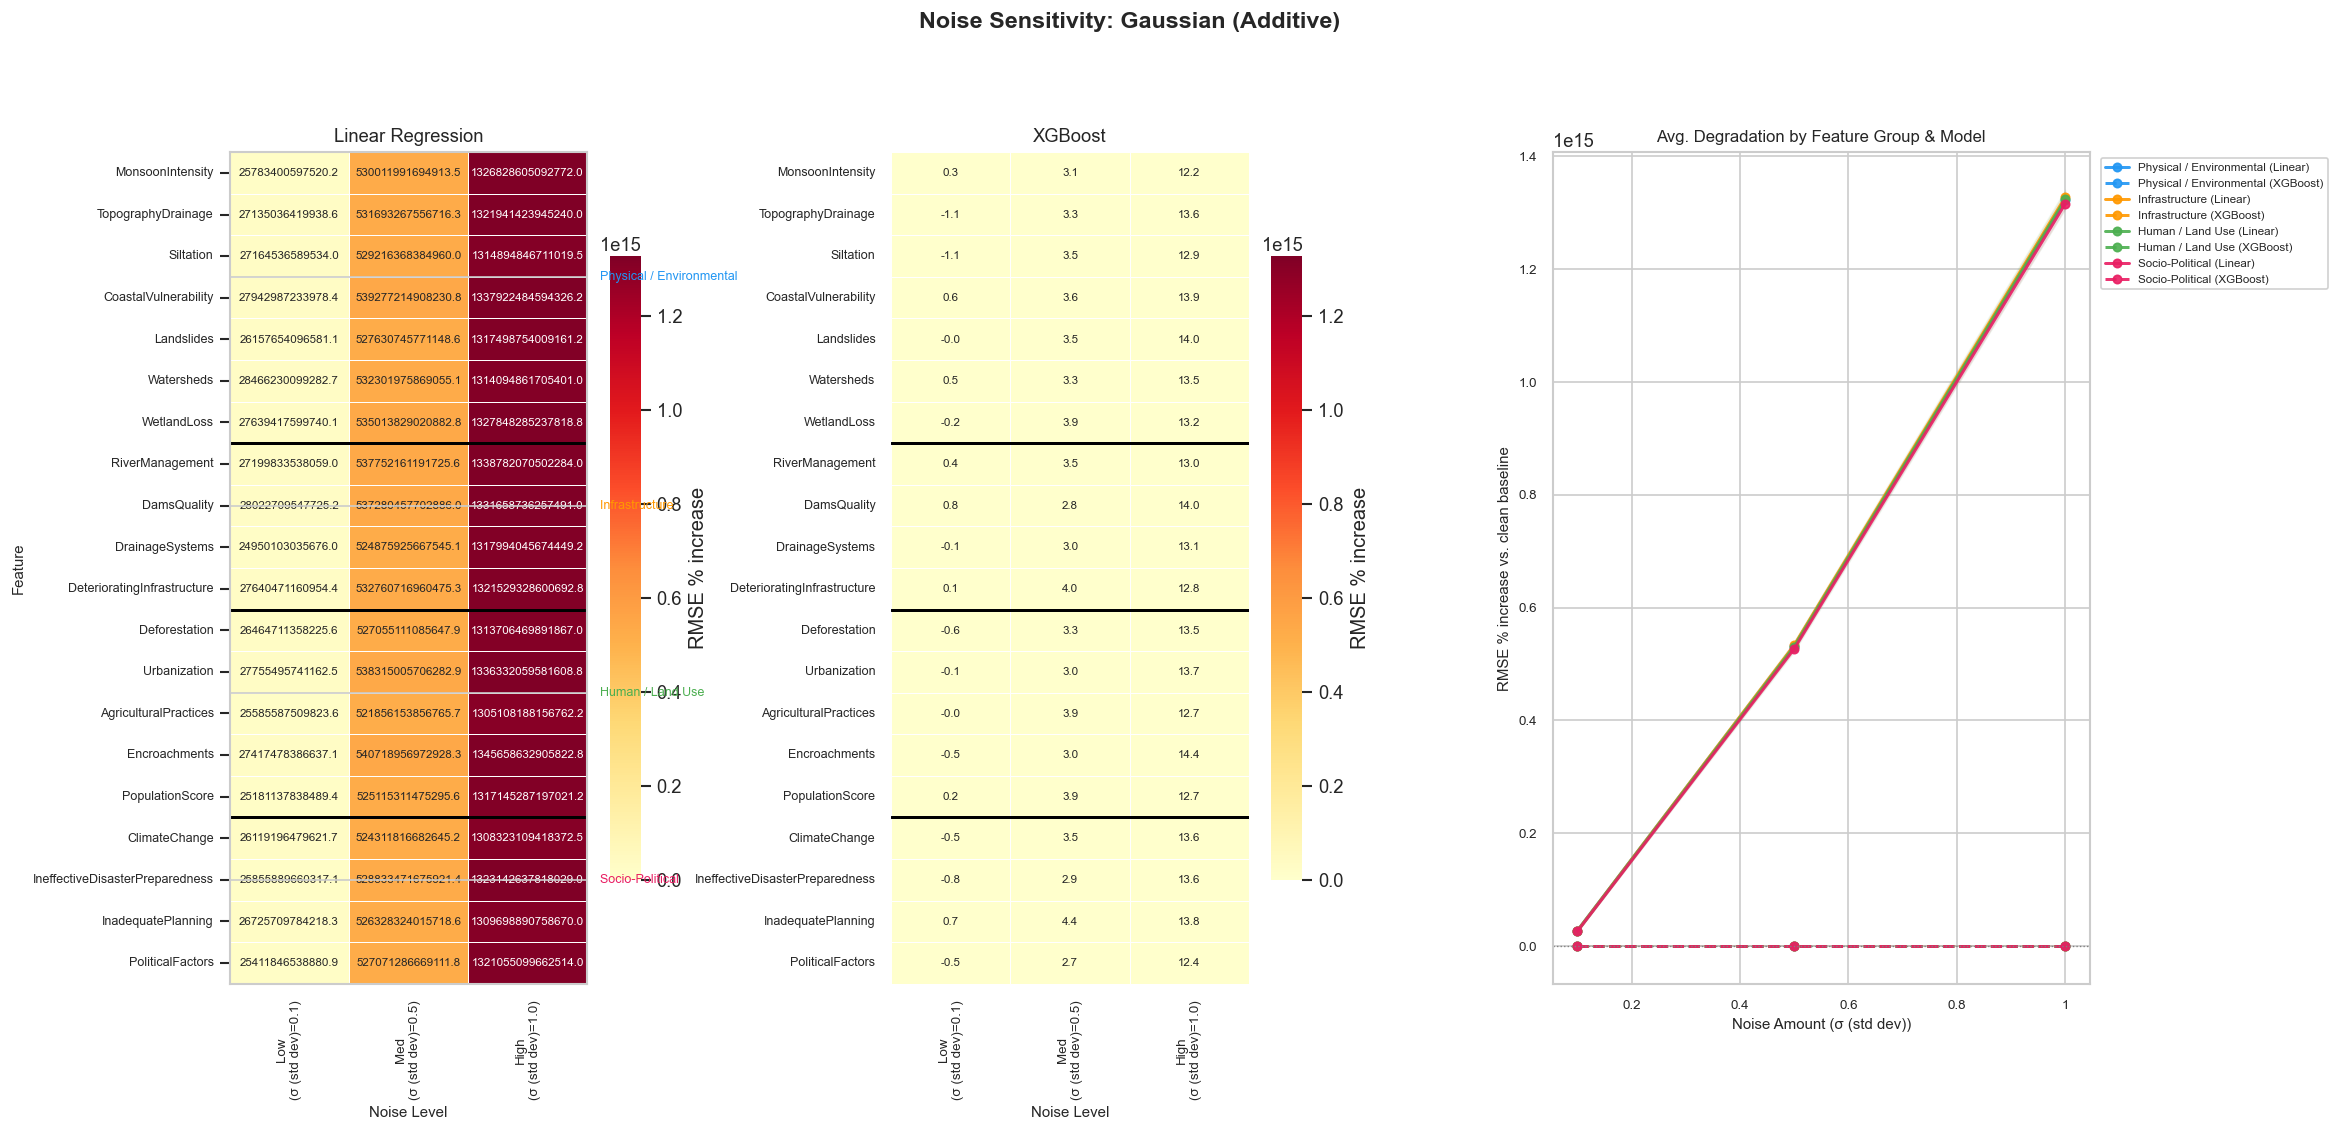

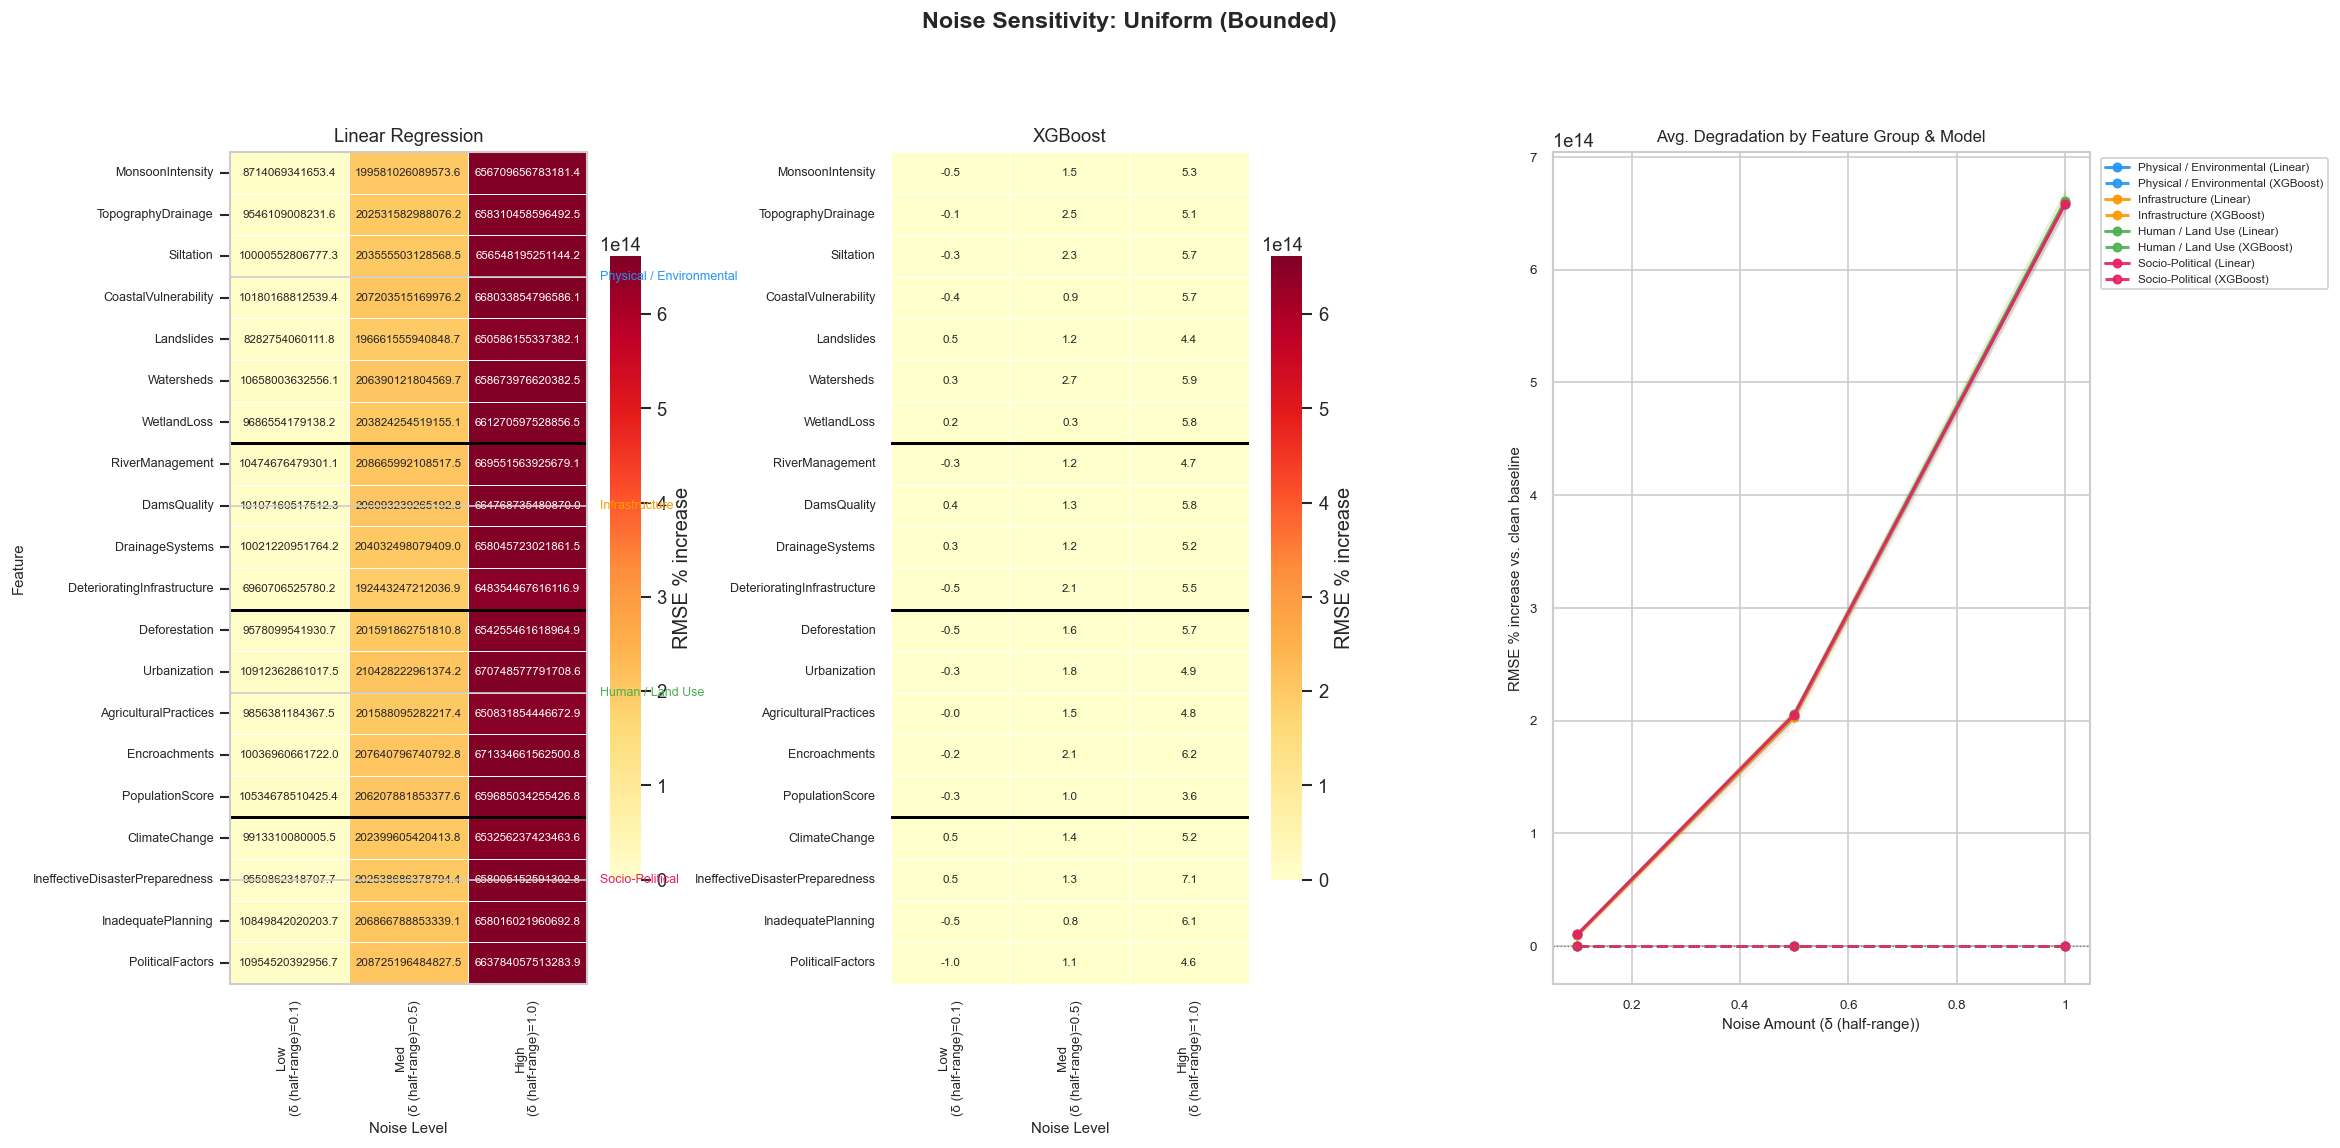

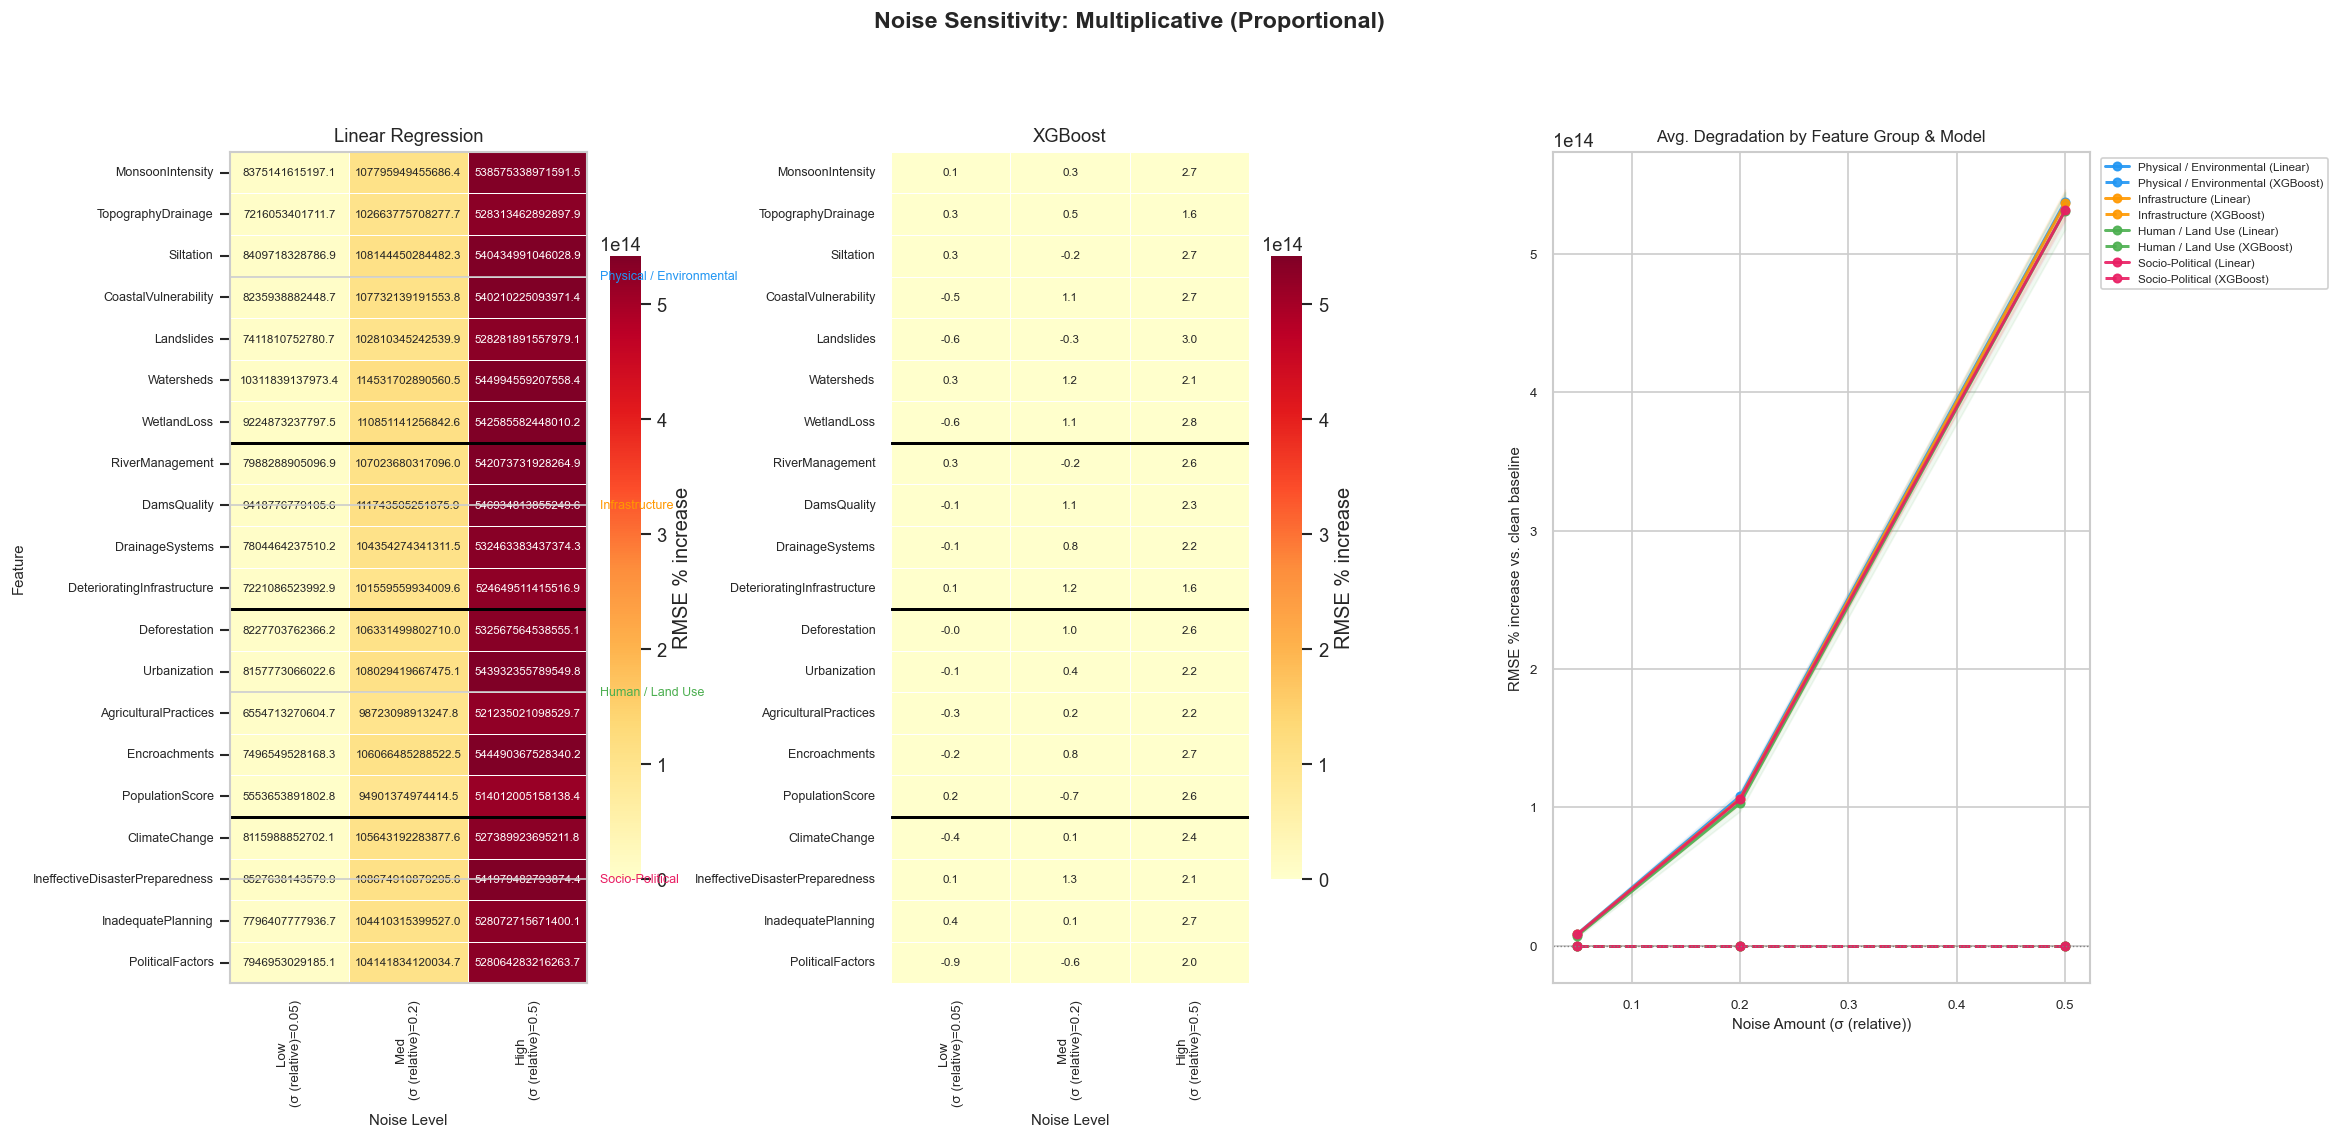

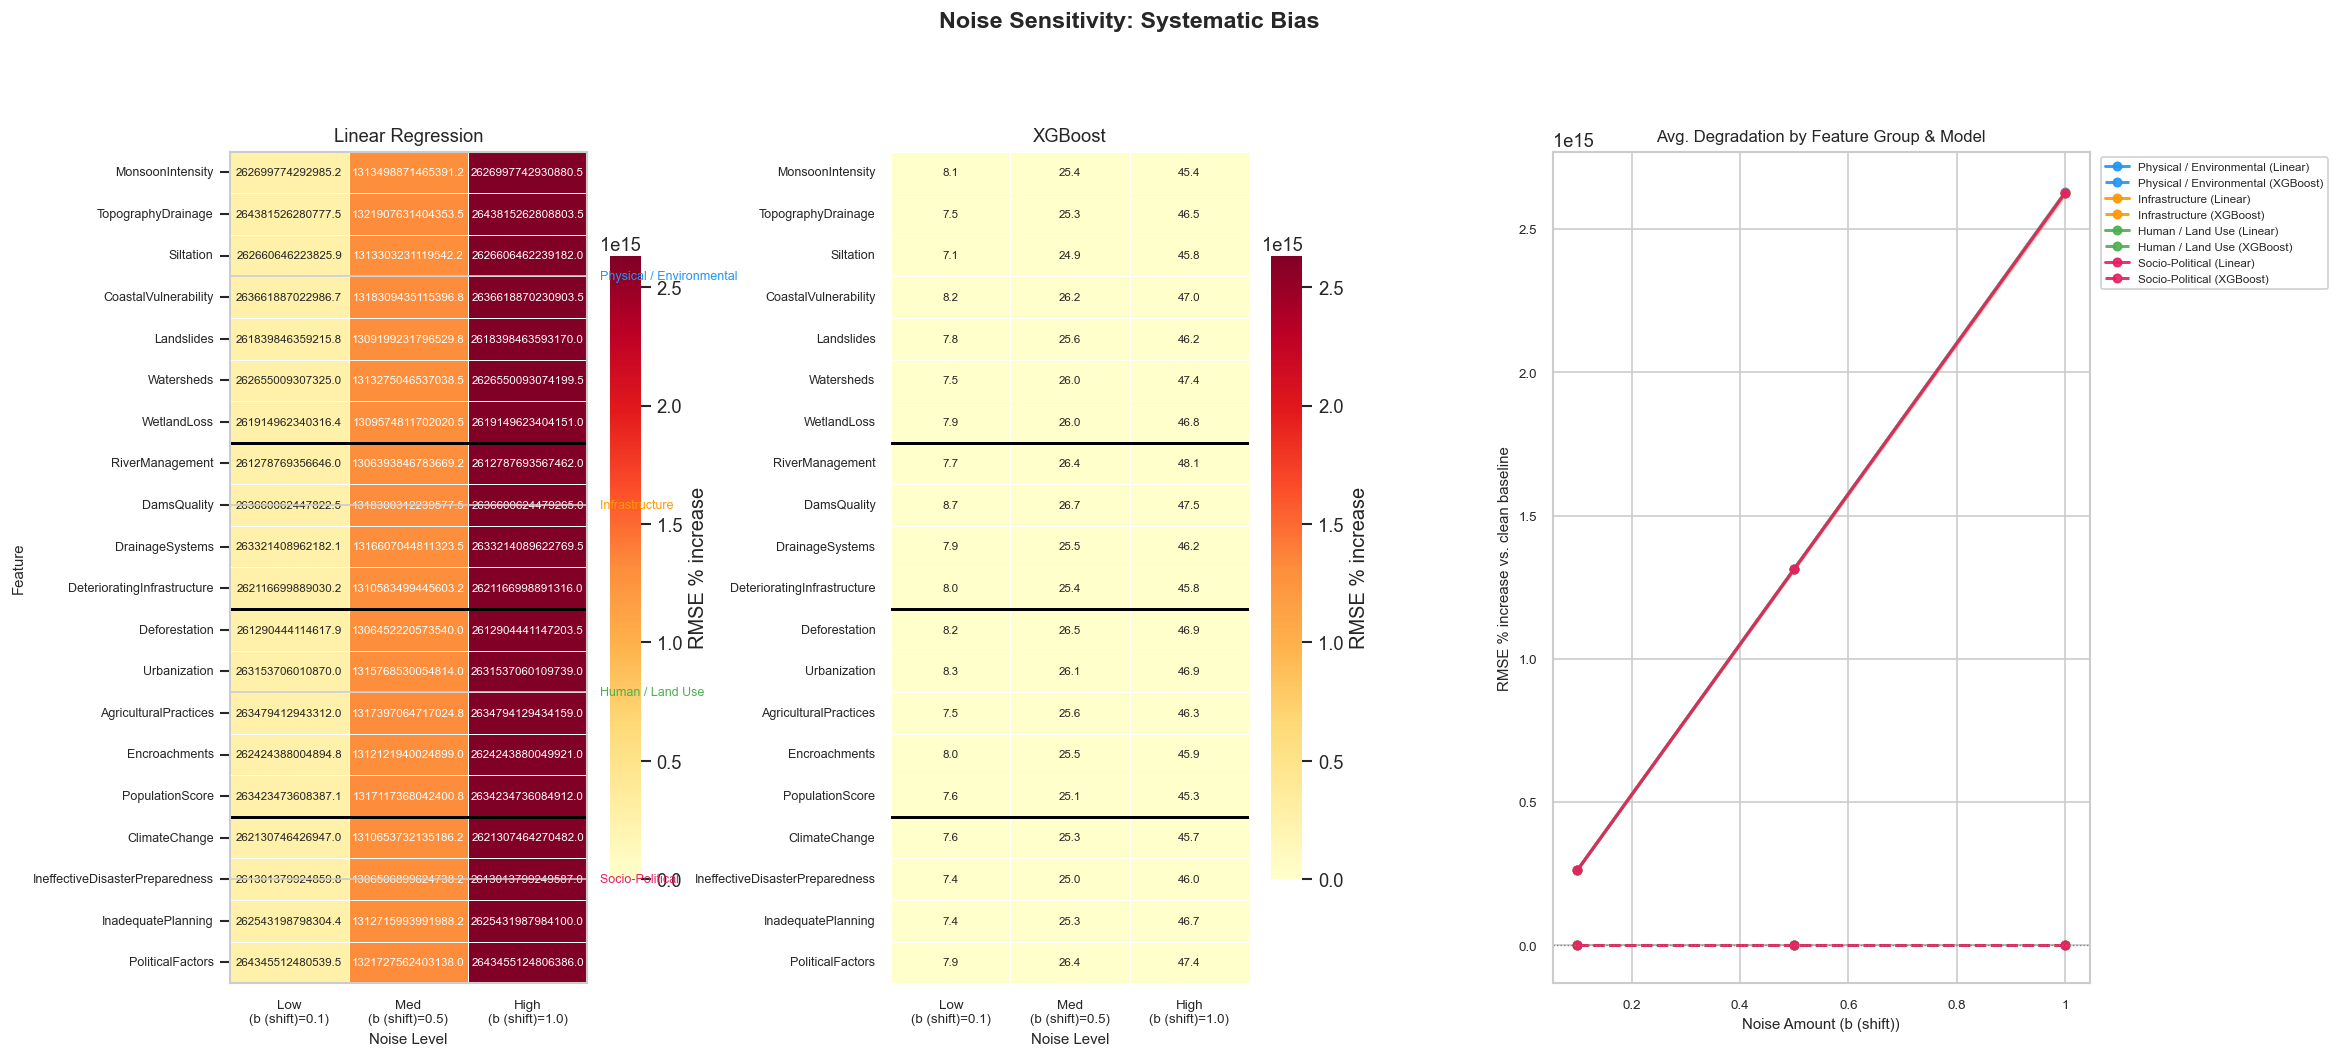

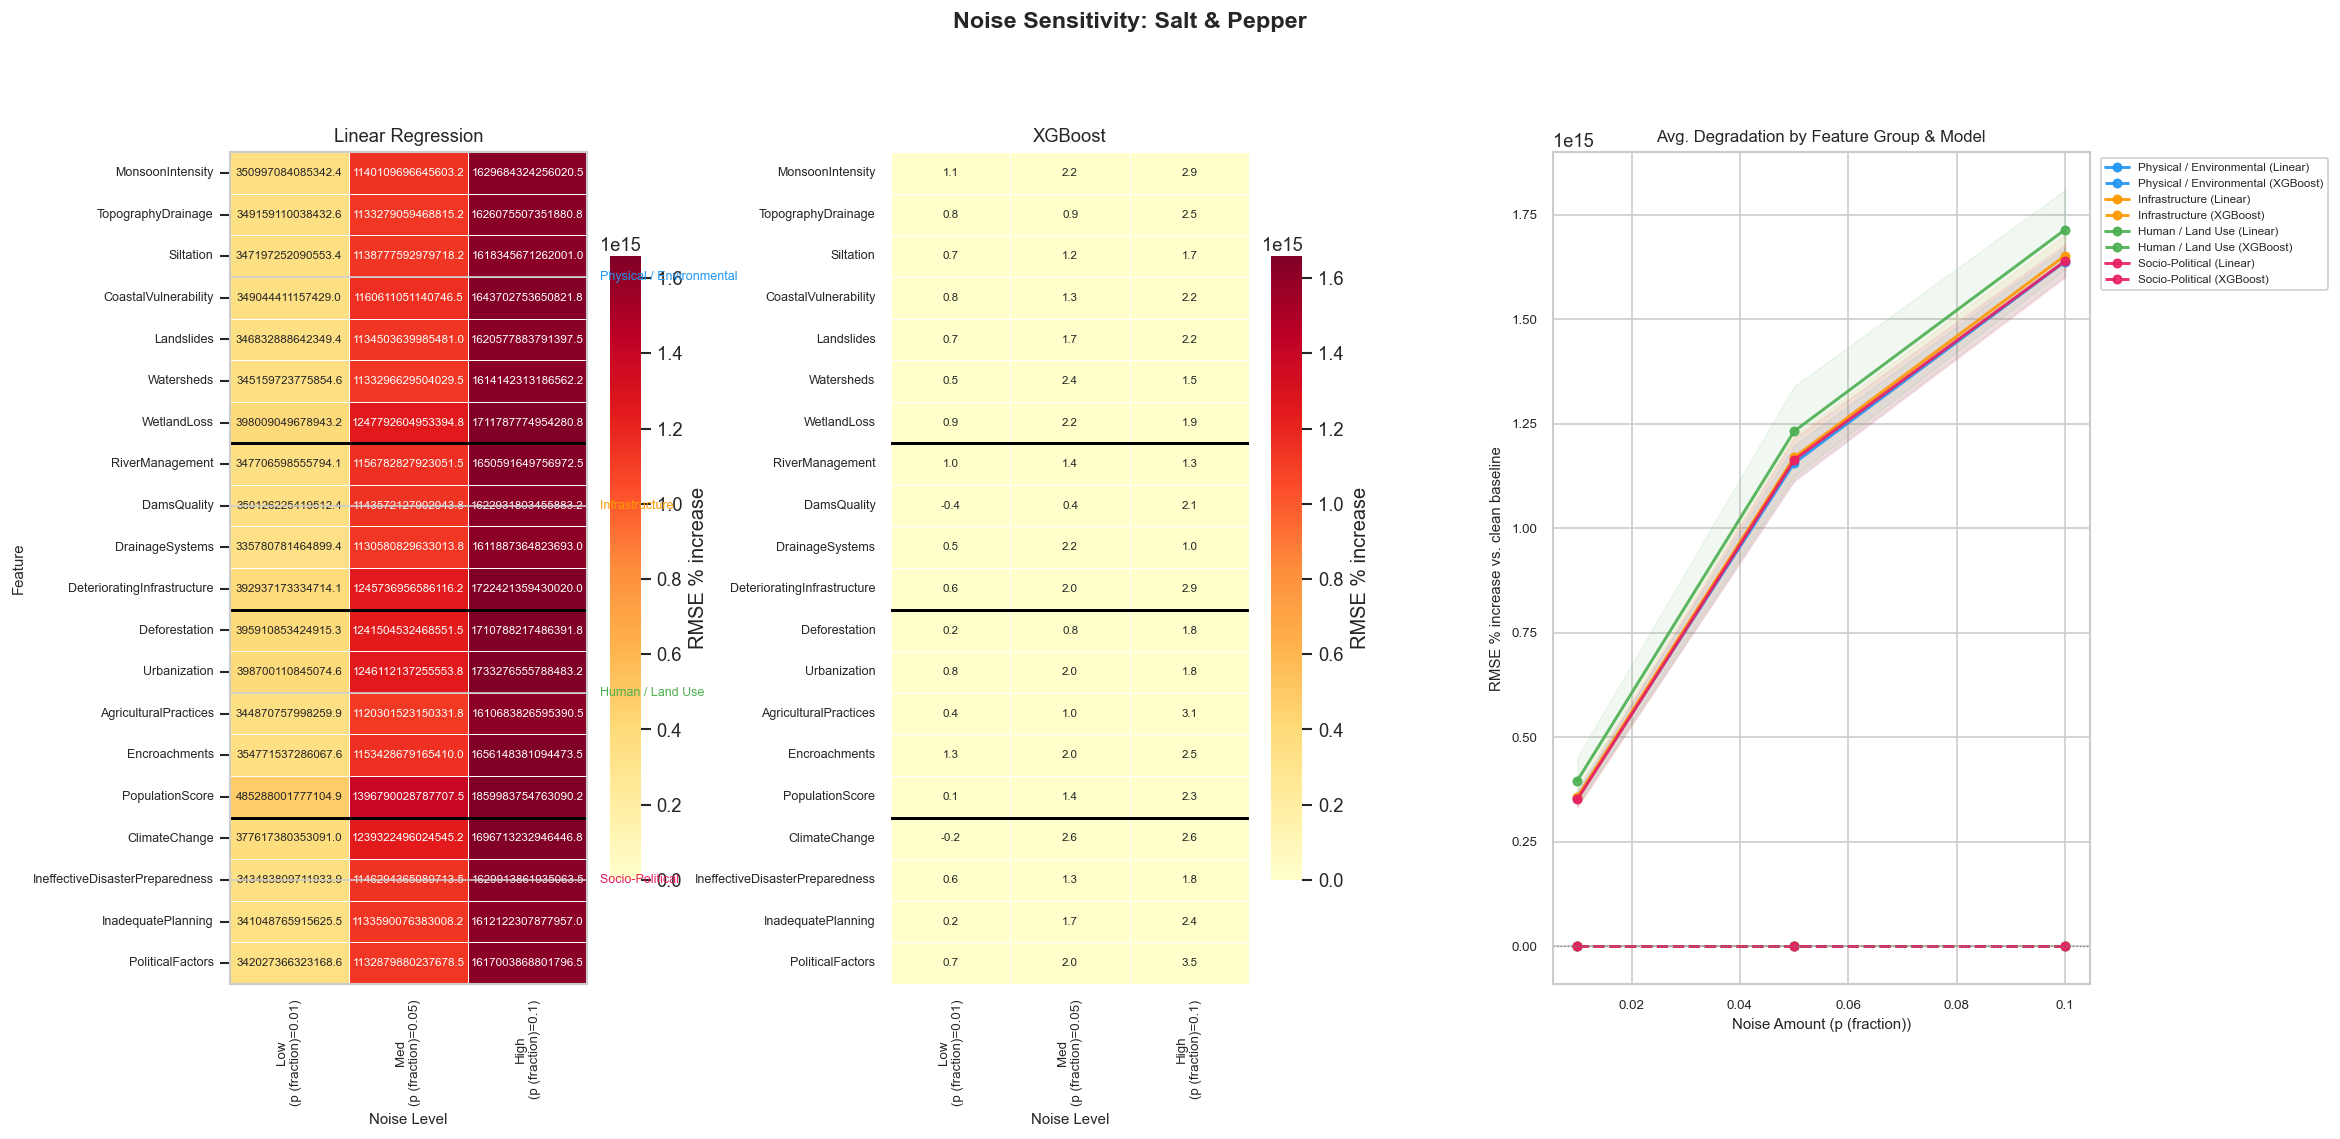

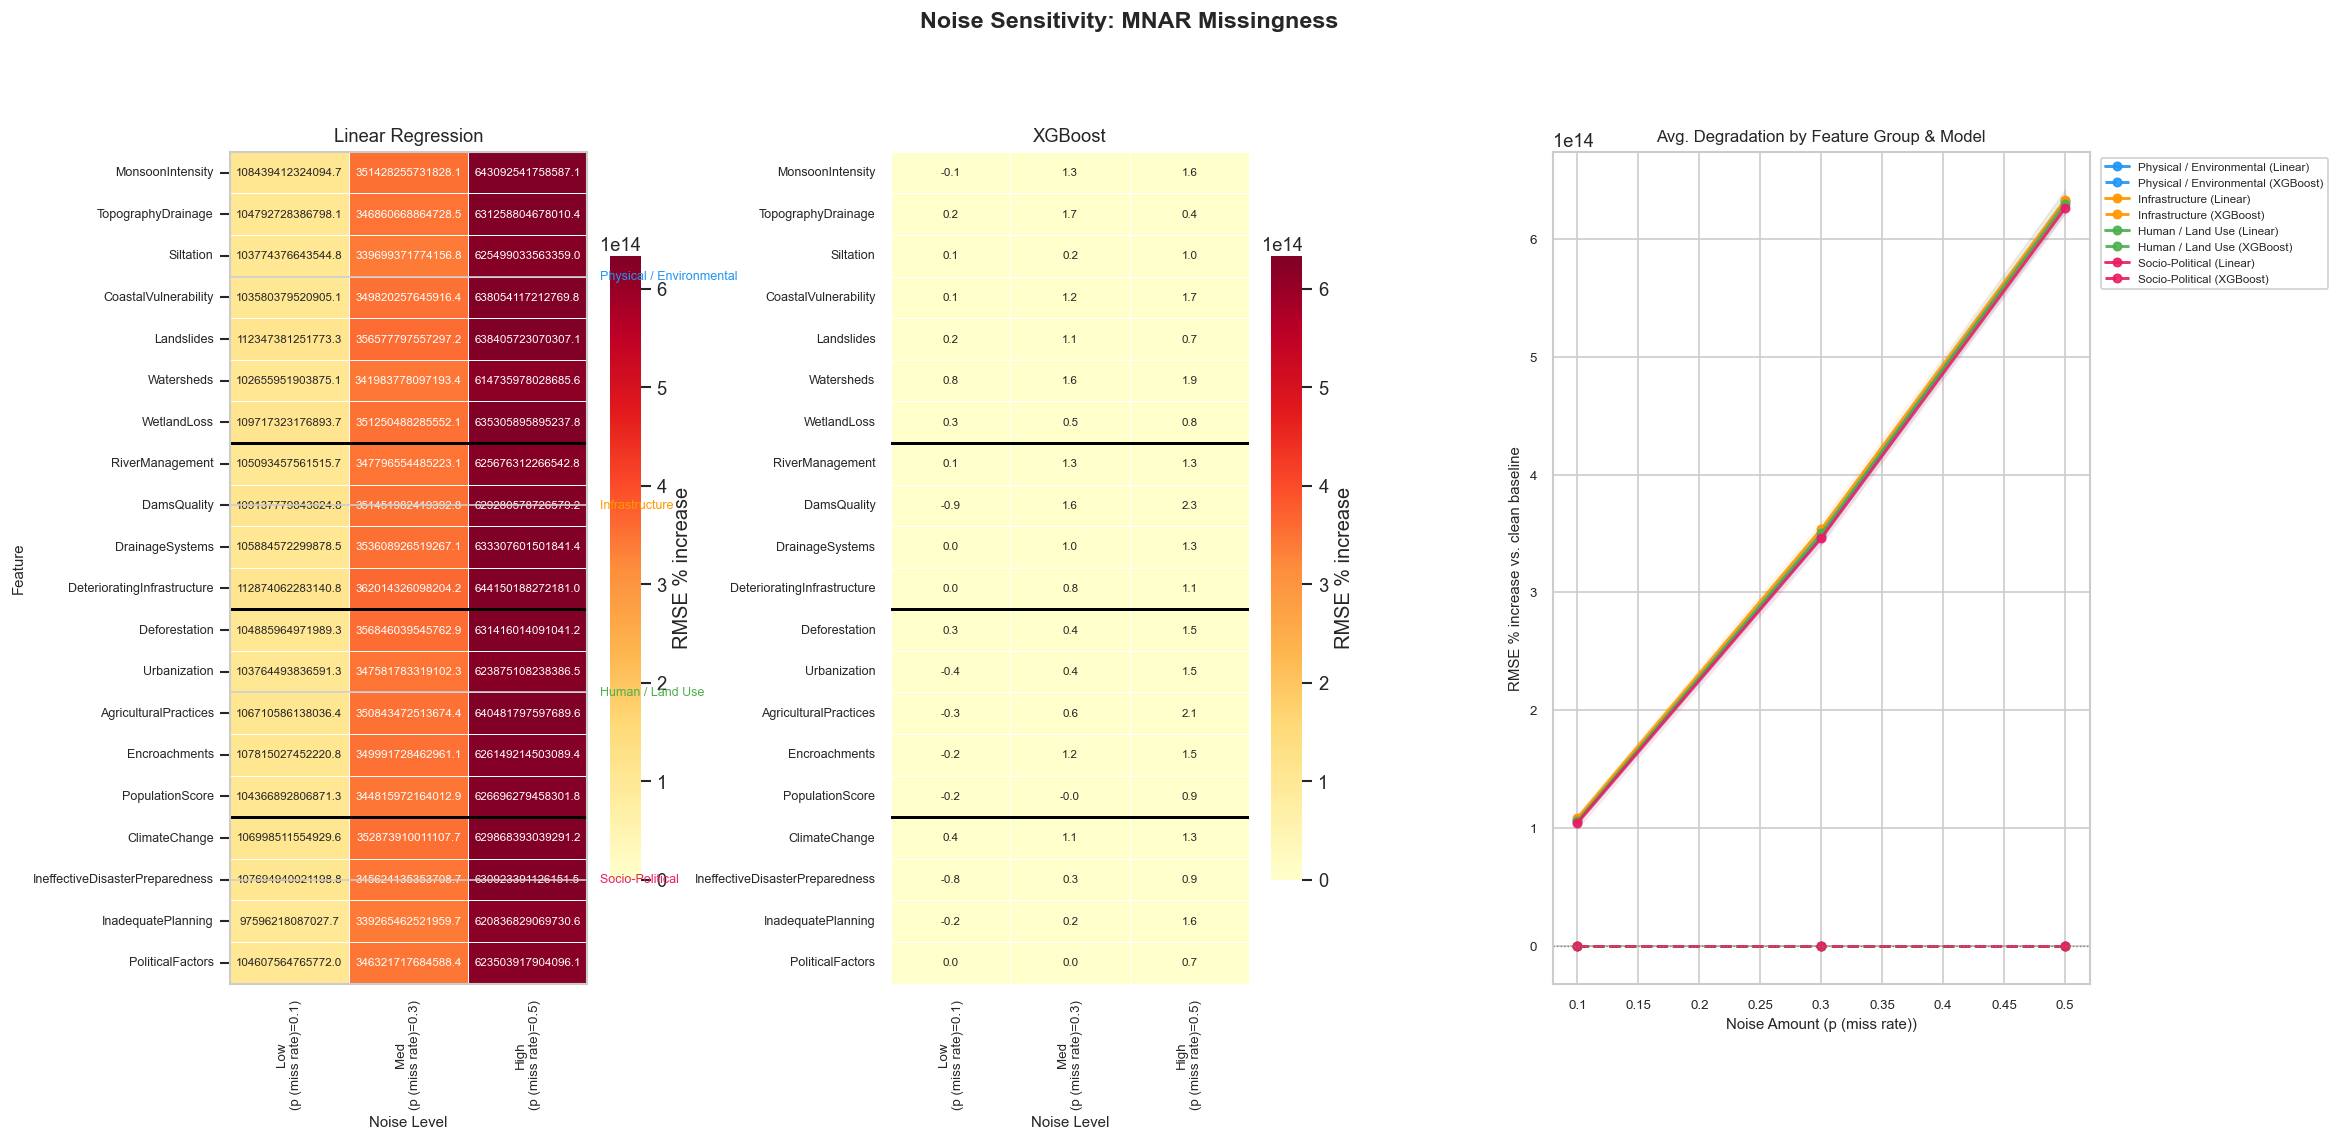

In [17]:
def group_boundaries(feat_order):
    bounds, prev = [], None
    for i, f in enumerate(feat_order):
        g = FEAT_TO_GROUP.get(f, "Other")
        if g != prev and prev is not None:
            bounds.append(i)
        prev = g
    return bounds


def group_label_positions(feat_order):
    positions, labels = [], []
    prev, start = None, 0
    for i, f in enumerate(feat_order):
        g = FEAT_TO_GROUP.get(f, "Other")
        if g != prev:
            if prev is not None:
                positions.append((start + i - 1) / 2)
                labels.append(prev)
            start = i
            prev = g
    positions.append((start + len(feat_order) - 1) / 2)
    labels.append(prev)
    return positions, labels


def plot_noise_type(noise_type, results_df, cfg):
    df_sub = results_df[results_df["noise_type"] == noise_type].copy()
    amounts = cfg["amounts"]
    amt_label = cfg["label"]
    title = NOISE_LABELS[noise_type]
    model_names = list(MODELS.keys())
    level_lbls = [
        f"Low\n({amt_label}={amounts[0]})",
        f"Med\n({amt_label}={amounts[1]})",
        f"High\n({amt_label}={amounts[2]})",
    ]

    fig = plt.figure(figsize=(20, 9))
    fig.suptitle(f"Noise Sensitivity: {title}", fontsize=14, fontweight="bold", y=1.01)
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.2], wspace=0.45)
    vmax = max(df_sub["rmse_pct"].abs().quantile(0.95), 0.5)

    # heatmaps for each model — showing % RMSE increase by feature & noise level
    for mi, model_name in enumerate(model_names):
        ax = fig.add_subplot(gs[0, mi])
        sub = df_sub[df_sub["model"] == model_name]
        pivot = sub.pivot_table(
            index="feature", columns="amount", values="rmse_pct"
        ).reindex(index=FEAT_ORDER)
        pivot.columns = level_lbls

        sns.heatmap(
            pivot,
            ax=ax,
            cmap="YlOrRd",
            vmin=0,
            vmax=vmax,
            annot=True,
            fmt=".1f",
            linewidths=0.4,
            cbar_kws={"label": "RMSE % increase", "shrink": 0.75},
            annot_kws={"size": 7},
        )
        ax.set_title(model_name, fontsize=11, pad=6)
        ax.set_xlabel("Noise Level", fontsize=9)
        ax.set_ylabel("Feature" if mi == 0 else "", fontsize=9)
        ax.tick_params(axis="y", labelsize=7.5)
        ax.tick_params(axis="x", labelsize=8)

        for b in group_boundaries(FEAT_ORDER):
            ax.axhline(b, color="black", linewidth=1.8)

        if mi == 0:
            positions, labels = group_label_positions(FEAT_ORDER)
            ax2 = ax.twinx()
            ax2.set_ylim(ax.get_ylim())
            ax2.set_yticks(positions)
            ax2.set_yticklabels(
                [f"  {l}" for l in labels], fontsize=7.5, rotation=0, va="center"
            )
            ax2.tick_params(length=0)
            for tick, lbl in zip(ax2.get_yticklabels(), labels):
                tick.set_color(GROUP_COLORS.get(lbl, "black"))

    # line plot of average degradation by group & model
    ax_line = fig.add_subplot(gs[0, 2])

    for group_name in GROUP_ORDER:
        color = GROUP_COLORS[group_name]
        group_feats = [f for f in FEATURE_GROUPS[group_name] if f in FEATURES]

        for model_name, ls in zip(model_names, ["-", "--"]):
            sub = df_sub[
                (df_sub["model"] == model_name) & (df_sub["feature"].isin(group_feats))
            ]
            grp = sub.groupby("amount")["rmse_pct"].agg(["mean", "std"]).reset_index()
            ax_line.plot(
                grp["amount"],
                grp["mean"],
                marker="o",
                linestyle=ls,
                color=color,
                linewidth=1.8,
                markersize=5,
                alpha=0.9,
                label=f"{group_name} ({model_name.split()[0]})",
            )
            ax_line.fill_between(
                grp["amount"],
                grp["mean"] - grp["std"],
                grp["mean"] + grp["std"],
                color=color,
                alpha=0.08,
            )

    ax_line.axhline(0, color="gray", linewidth=0.8, linestyle=":")
    ax_line.set_xlabel(f"Noise Amount ({amt_label})", fontsize=9)
    ax_line.set_ylabel("RMSE % increase vs. clean baseline", fontsize=9)
    ax_line.set_title("Avg. Degradation by Feature Group & Model", fontsize=10)
    ax_line.legend(
        fontsize=7, loc="upper left", ncol=1, framealpha=0.9, bbox_to_anchor=(1.01, 1)
    )
    ax_line.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2g"))
    ax_line.tick_params(labelsize=8)

    plt.tight_layout()
    plt.show()


for noise_type, cfg in NOISE_CONFIG.items():
    plot_noise_type(noise_type, results, cfg)

## 10. Summary Bar Chart: Most Vulnerable Features
Averaged across all noise types at high noise level.

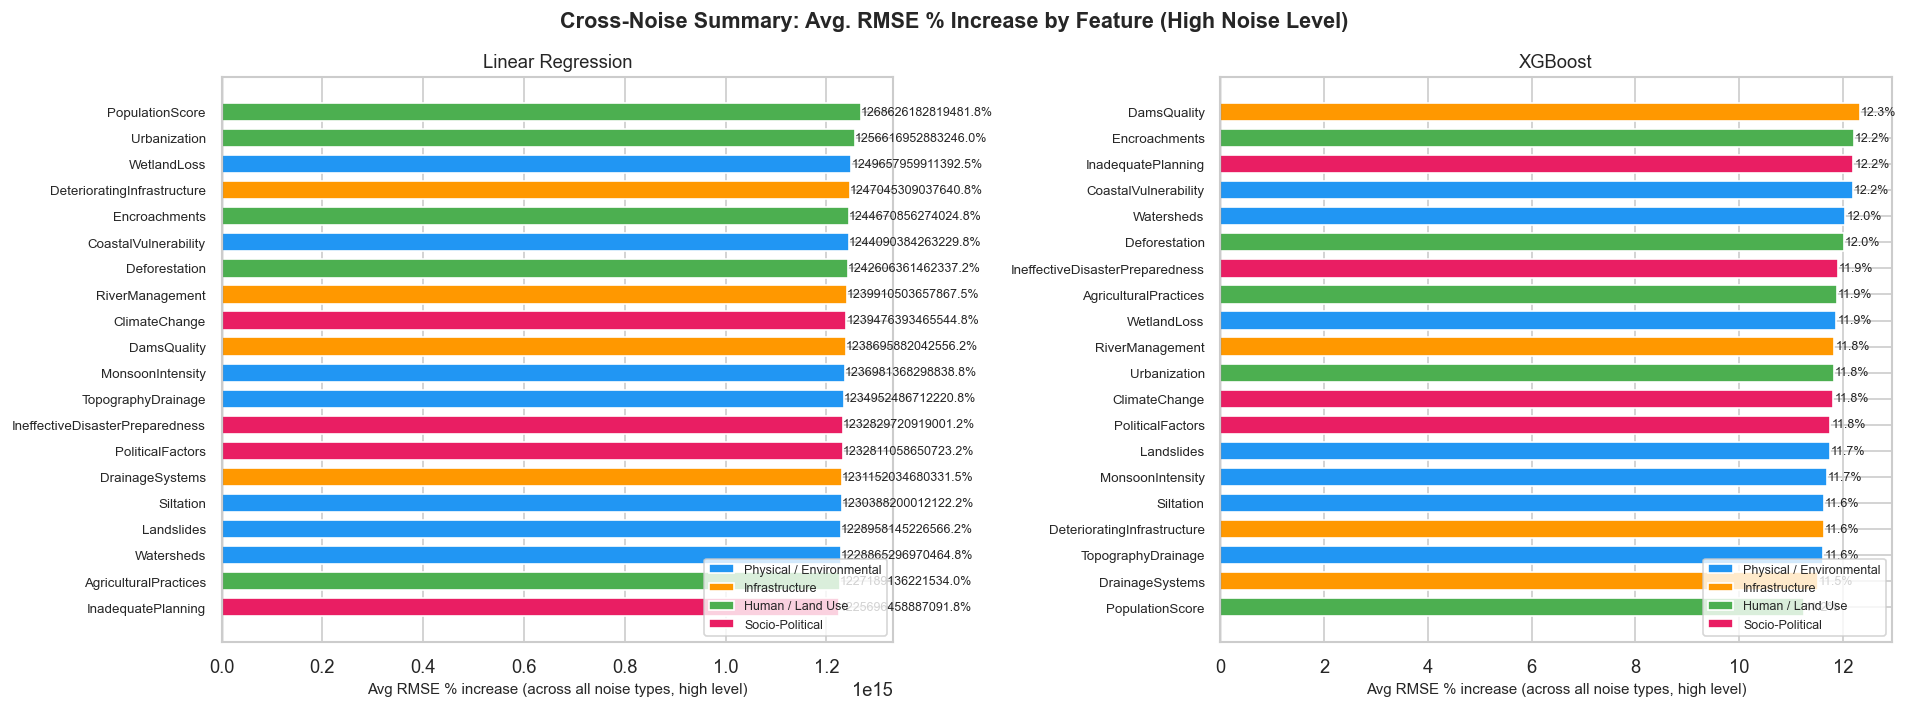

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Cross-Noise Summary: Avg. RMSE % Increase by Feature (High Noise Level)",
    fontsize=13,
    fontweight="bold",
)
high = results[results["amount_level"] == 2]

for ax, model_name in zip(axes, list(MODELS.keys())):
    sub = high[high["model"] == model_name]
    feat_summary = (
        sub.groupby(["feature", "feature_group"])["rmse_pct"]
        .mean()
        .reset_index()
        .sort_values("rmse_pct", ascending=True)
    )
    colors = [GROUP_COLORS.get(g, "gray") for g in feat_summary["feature_group"]]
    bars = ax.barh(
        feat_summary["feature"],
        feat_summary["rmse_pct"],
        color=colors,
        edgecolor="white",
        height=0.7,
    )
    for bar, val in zip(bars, feat_summary["rmse_pct"]):
        ax.text(
            val + 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%",
            va="center",
            ha="left",
            fontsize=7.5,
        )
    ax.set_title(model_name, fontsize=11)
    ax.set_xlabel(
        "Avg RMSE % increase (across all noise types, high level)", fontsize=9
    )
    ax.tick_params(axis="y", labelsize=8)
    ax.axvline(0, color="gray", linewidth=0.8)
    legend_handles = [Patch(facecolor=GROUP_COLORS[g], label=g) for g in GROUP_ORDER]
    ax.legend(handles=legend_handles, fontsize=7.5, loc="lower right")

plt.tight_layout()
plt.show()

## 11. Cross-Noise Heatmap: Feature × Noise Type

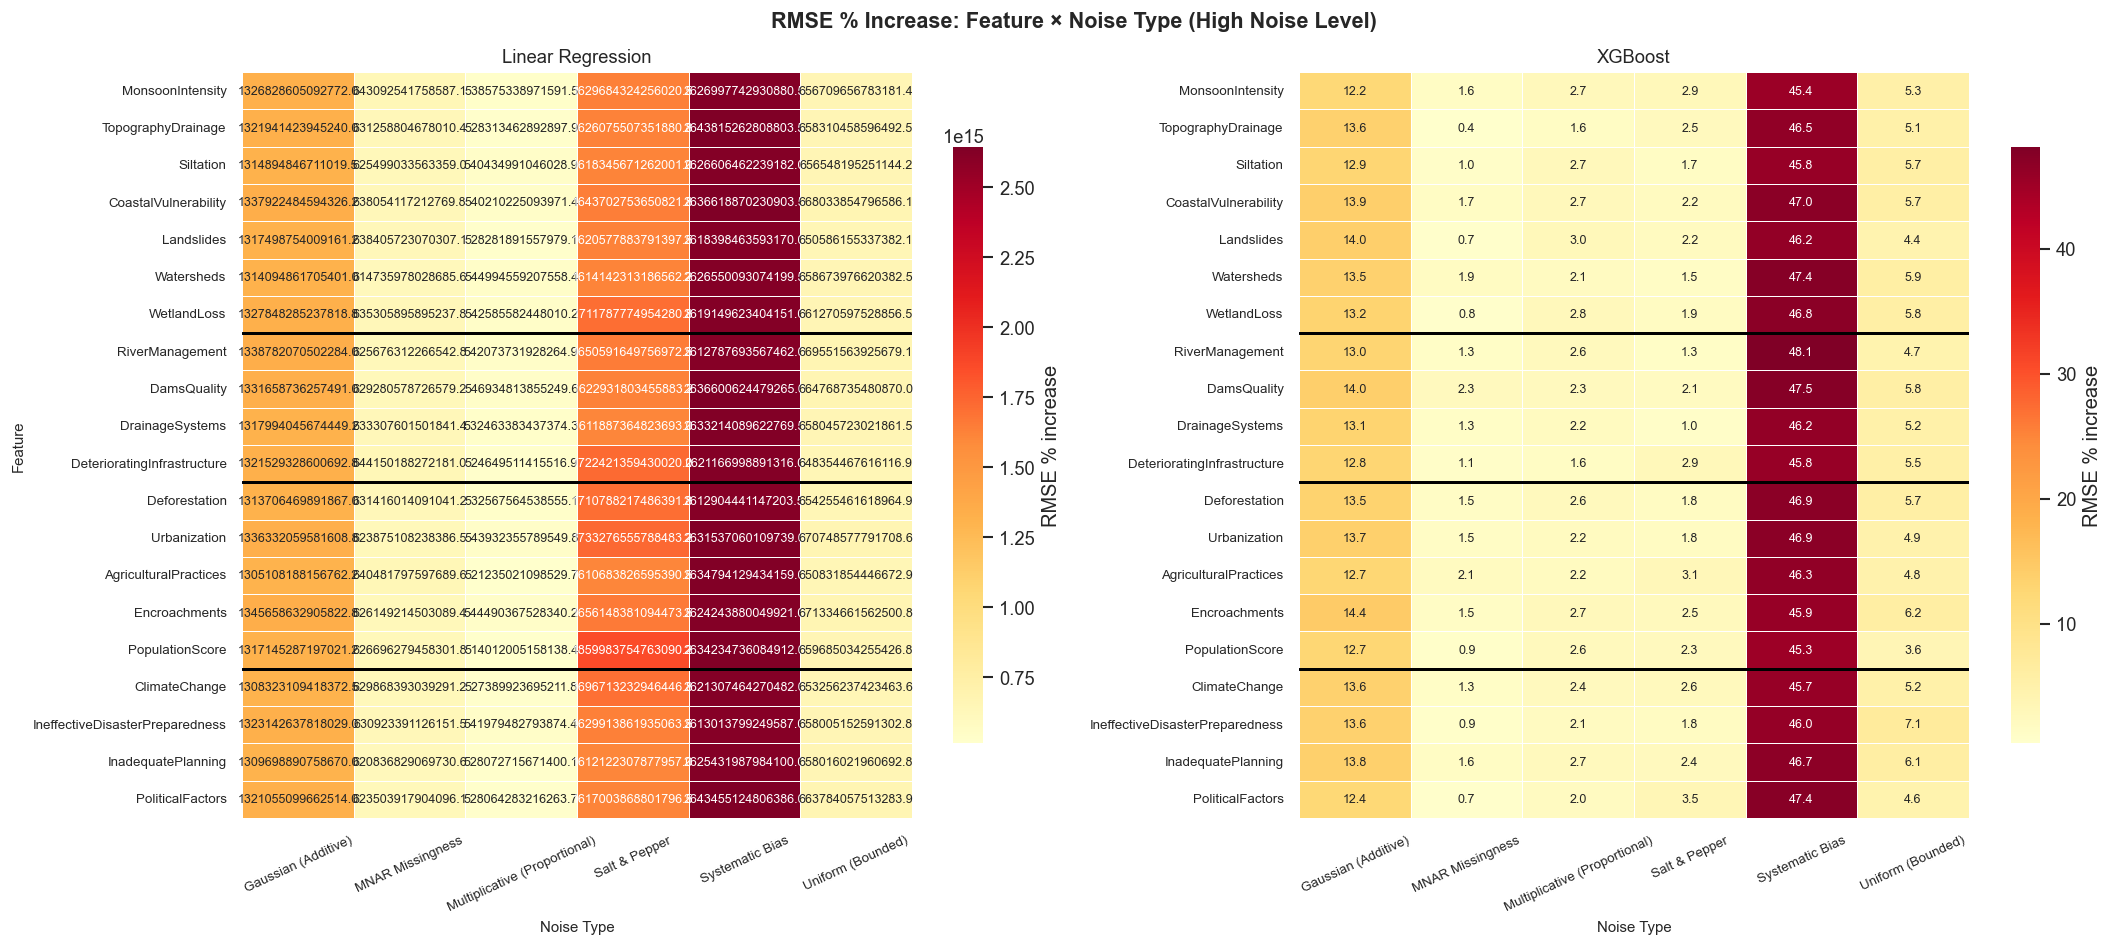

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle(
    "RMSE % Increase: Feature × Noise Type (High Noise Level)",
    fontsize=13,
    fontweight="bold",
)
high = results[results["amount_level"] == 2]

for ax, model_name in zip(axes, list(MODELS.keys())):
    sub = high[high["model"] == model_name]
    pivot = sub.pivot_table(
        index="feature", columns="noise_label", values="rmse_pct"
    ).reindex(index=FEAT_ORDER)
    sns.heatmap(
        pivot,
        ax=ax,
        cmap="YlOrRd",
        annot=True,
        fmt=".1f",
        linewidths=0.4,
        cbar_kws={"label": "RMSE % increase", "shrink": 0.8},
        annot_kws={"size": 7.5},
    )
    ax.set_title(model_name, fontsize=11)
    ax.set_xlabel("Noise Type", fontsize=9)
    ax.set_ylabel("Feature" if ax is axes[0] else "", fontsize=9)
    ax.tick_params(axis="y", labelsize=8)
    ax.tick_params(axis="x", labelsize=8, rotation=25)
    for b in group_boundaries(FEAT_ORDER):
        ax.axhline(b, color="black", linewidth=1.8)

plt.tight_layout()
plt.show()

## 12. Save Experiment Results

In [20]:
results.to_csv("data/noise_experiment_results.csv", index=False)
print(f"Saved: data/noise_experiment_results.csv ({len(results):,} rows)")

print("\nTop 10 most impactful (feature, noise_type) — XGBoost, high noise:")
display(
    results[(results["model"] == "XGBoost") & (results["amount_level"] == 2)]
    .sort_values("rmse_pct", ascending=False)[
        ["feature", "noise_label", "amount", "rmse_pct", "r2"]
    ]
    .head(10)
    .reset_index(drop=True)
    .style.format({"rmse_pct": "{:.2f}%", "r2": "{:.4f}"})
)

Saved: data/noise_experiment_results.csv (720 rows)

Top 10 most impactful (feature, noise_type) — XGBoost, high noise:


,feature,noise_label,amount,rmse_pct,r2
0,RiverManagement,Systematic Bias,1.000000,48.14%,0.8947
1,DamsQuality,Systematic Bias,1.000000,47.51%,0.8956
2,Watersheds,Systematic Bias,1.000000,47.44%,0.8957
3,PoliticalFactors,Systematic Bias,1.000000,47.39%,0.8958
4,CoastalVulnerability,Systematic Bias,1.000000,46.98%,0.8964
5,Deforestation,Systematic Bias,1.000000,46.95%,0.8964
6,Urbanization,Systematic Bias,1.000000,46.87%,0.8965
7,WetlandLoss,Systematic Bias,1.000000,46.84%,0.8966
8,InadequatePlanning,Systematic Bias,1.000000,46.70%,0.8968
9,TopographyDrainage,Systematic Bias,1.000000,46.46%,0.8971


## 13. Apply Experimentally-Informed Noise & Save Model-Ready Splits

Based on the experiment results above, apply the noise types and levels that were
shown to have meaningful (but not catastrophic) impact on each feature group.

**Review Sections 9–11 and update `GROUP_NOISE_POLICY` before running this cell.**
The defaults below are a starting point — adjust based on what our plots show.

In [ ]:
# Print a ranked sensitivity table to help us decide
print("Feature sensitivity ranking — Gaussian, medium level, XGBoost:")
ranking = (
    results[
        (results["model"] == "XGBoost")
        & (results["amount_level"] == 1)
        & (results["noise_type"] == "gaussian")
    ]
    .groupby(["feature", "feature_group"])["rmse_pct"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
print(ranking.to_string(index=False))

Feature sensitivity ranking — Gaussian, medium level, XGBoost:
                        feature            feature_group  rmse_pct
             InadequatePlanning          Socio-Political  4.439471
    DeterioratingInfrastructure           Infrastructure  3.952599
                    WetlandLoss Physical / Environmental  3.910938
                PopulationScore         Human / Land Use  3.890718
          AgriculturalPractices         Human / Land Use  3.858318
           CoastalVulnerability Physical / Environmental  3.618148
                      Siltation Physical / Environmental  3.482099
                  ClimateChange          Socio-Political  3.471840
                RiverManagement           Infrastructure  3.456457
                     Landslides Physical / Environmental  3.455522
             TopographyDrainage Physical / Environmental  3.288581
                  Deforestation         Human / Land Use  3.267576
                     Watersheds Physical / Environmental  3.254701

In [ ]:
# ! Update this dict based on experiment findings from above !
# Format: group -> (noise_type, amount)
# Use medium noise levels (amount_level=1) as the default —
# enough to stress the model without destroying signal.

GROUP_NOISE_POLICY = {
    # Systematic bias is the most damaging — use medium level (0.5)
    # for socio-political features since they're most likely to be
    # systematically misreported
    "Socio-Political": ("bias", 0.5),
    # Infrastructure is realistically subject to MNAR (poor regions
    # don't report) — but since XGBoost handles it well, use high level
    "Infrastructure": ("mnar", 0.3),
    # Physical features: Gaussian at medium — sensor error
    "Physical / Environmental": ("gaussian", 0.5),
    # Human/Land Use: Gaussian at low — satellite data is fairly reliable
    "Human / Land Use": ("gaussian", 0.1),
}

X_train_noisy = X_train_clean.copy()

for group, (noise_type, amount) in GROUP_NOISE_POLICY.items():
    group_feats = [f for f in FEATURE_GROUPS[group] if f in FEATURES]
    for feat in group_feats:
        X_train_noisy = inject_noise(X_train_noisy, feat, noise_type, amount)
    print(f"{group:30s}: {noise_type} (amount={amount}) → {group_feats}")

print(f"\nX_train_noisy shape : {X_train_noisy.shape}")
print(f"X_test_clean  shape : {X_test_clean.shape}  ← untouched")

Socio-Political               : bias (amount=0.5) → ['ClimateChange', 'IneffectiveDisasterPreparedness', 'InadequatePlanning', 'PoliticalFactors']
Infrastructure                : mnar (amount=0.3) → ['RiverManagement', 'DamsQuality', 'DrainageSystems', 'DeterioratingInfrastructure']
Physical / Environmental      : gaussian (amount=0.5) → ['MonsoonIntensity', 'TopographyDrainage', 'Siltation', 'CoastalVulnerability', 'Landslides', 'Watersheds', 'WetlandLoss']
Human / Land Use              : gaussian (amount=0.1) → ['Deforestation', 'Urbanization', 'AgriculturalPractices', 'Encroachments', 'PopulationScore']

X_train_noisy shape : (40000, 20)
X_test_clean  shape : (10000, 20)  ← untouched


In [23]:
# Sanity check: how much did noise affect performance?
for model_name in MODELS:
    mdl = (
        LinearRegression()
        if model_name == "Linear Regression"
        else XGBRegressor(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.1,
            random_state=SEED,
            verbosity=0,
        )
    )
    mdl.fit(X_train_noisy, y_train)
    preds = mdl.predict(X_test_clean)
    noisy_rmse = np.sqrt(mean_squared_error(y_test, preds))
    base_rmse = baselines[model_name]["rmse"]
    print(
        f"{model_name:22s} | Noisy RMSE: {noisy_rmse:.4f} | "
        f"Baseline: {base_rmse:.4f} | "
    )

Linear Regression      | Noisy RMSE: 0.0281 | Baseline: 0.0000 | 
XGBoost                | Noisy RMSE: 0.0383 | Baseline: 0.0109 | 


## 14. Save Final Model-Ready Splits

In [24]:
# Training: noisy features + clean target
train_out = X_train_noisy.copy()
train_out[TARGET] = y_train.values

# Test: clean features + clean target (never noised)
test_out = X_test_clean.copy()
test_out[TARGET] = y_test.values

train_out.to_csv("data/flood_train_scaled.csv", index=False)
test_out.to_csv("data/flood_test_scaled.csv", index=False)

print("Saved:")
print(
    f"  data/flood_train_scaled.csv — noisy training features + target  {train_out.shape}"
)
print(
    f"  data/flood_test_scaled.csv  — clean test features + target       {test_out.shape}"
)
print("\nReady for 01_modeling.ipynb")

Saved:
  data/flood_train_scaled.csv — noisy training features + target  (40000, 21)
  data/flood_test_scaled.csv  — clean test features + target       (10000, 21)

Ready for 01_modeling.ipynb
